# Charge Curve Explainer

This notebook walks through the mathematics and implementation of the charge curve model used in `BayCalculator.py`.

The model simulates how long an EV occupies a charging bay by sampling a realistic session duration, taking into account:
- Which phase of charging the vehicle is in (constant-current vs. taper)
- Starting and target state-of-charge (SOC) drawn from statistical distributions
- Calibration to a reference session length
- Random jitter to model real-world variation

Three curve presets are available: `legacy` (fixed average), `ac_l2` (AC Level 2), and `dc_fast` (DC fast charger).

## 1. Imports

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Reproducible results for this explainer
random.seed(42)
np.random.seed(42)

print("Libraries loaded.")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded.


## 2. Curve Presets

Each charger type is described by four parameters stored in `CURVE_PRESETS`:

| Parameter | Meaning |
|---|---|
| `cc_soc` | State-of-charge at which constant-current (CC) phase ends |
| `cc_rate_soc_per_min` | Charging rate during the CC phase, expressed as SOC gained per minute |
| `taper_k` | Exponential decay rate of the taper phase (higher → faster taper) |
| `duration_scale` | Scales the raw computed minutes to account for real-world overhead |
| `duration_jitter` | Standard deviation for log-normal noise applied to each session |

In [2]:
CURVE_PRESETS = {
    "ac_l2": {
        "description": "AC Level 2 session profile with gradual taper",
        "cc_soc": 0.72,
        "cc_rate_soc_per_min": 0.009,
        "taper_k": 4.0,
        "duration_scale": 1.15,
        "duration_jitter": 0.12,
        "reference_minutes": 55.0,
    },
    "dc_fast": {
        "description": "DC fast charging profile with faster constant-power phase",
        "cc_soc": 0.80,
        "cc_rate_soc_per_min": 0.028,
        "taper_k": 6.5,
        "duration_scale": 0.78,
        "duration_jitter": 0.10,
        "reference_minutes": 28.0,
    },
}

for name, c in CURVE_PRESETS.items():
    print(f"{name}: {c['description']}")

ac_l2: AC Level 2 session profile with gradual taper
dc_fast: DC fast charging profile with faster constant-power phase


## 3. SOC Input Distributions

Each session starts with a randomly drawn initial SOC and a target SOC.

### Initial SOC — Beta distribution

$$\text{initial\_soc} \sim \text{Beta}(\alpha=2.2,\ \beta=4.8)$$

The Beta(2.2, 4.8) distribution is right-skewed toward lower SOC values, reflecting that most public chargers are used by drivers who arrive with a fairly low battery.

### Target SOC — Uniform distribution

$$\text{target\_soc} \sim \mathcal{U}(0.75,\ 0.90)$$

Drivers typically don't charge to 100 %; the model caps target SOC at 0.90 to reflect this behaviour. If the drawn target is at or below the initial SOC, it is nudged to `initial_soc + 0.10` (capped at 0.95).

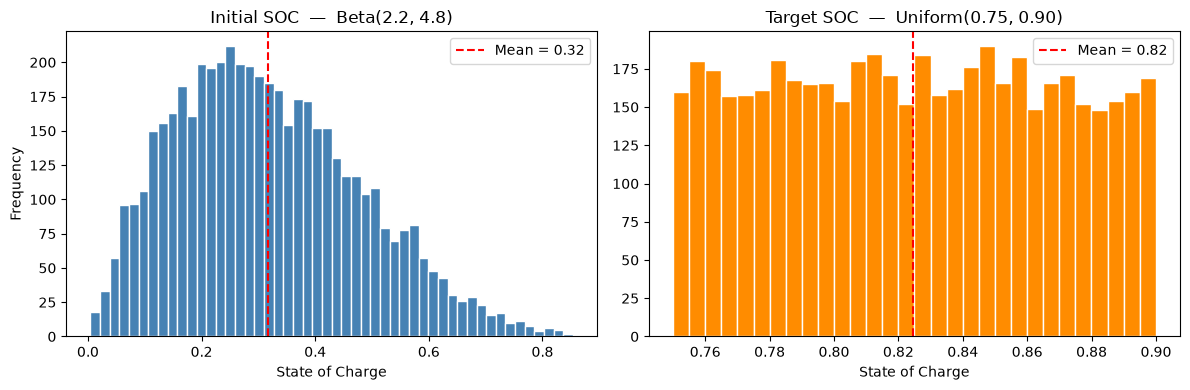

Initial SOC  →  mean=0.318, std=0.162
Target SOC   →  mean=0.824, std=0.043


In [3]:
n_samples = 5000
initial_socs = np.random.beta(2.2, 4.8, n_samples)
target_socs = np.random.uniform(0.75, 0.90, n_samples)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(initial_socs, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Initial SOC  —  Beta(2.2, 4.8)")
axes[0].set_xlabel("State of Charge")
axes[0].set_ylabel("Frequency")
axes[0].axvline(initial_socs.mean(), color="red", linestyle="--", label=f"Mean = {initial_socs.mean():.2f}")
axes[0].legend()

axes[1].hist(target_socs, bins=30, color="darkorange", edgecolor="white")
axes[1].set_title("Target SOC  —  Uniform(0.75, 0.90)")
axes[1].set_xlabel("State of Charge")
axes[1].axvline(target_socs.mean(), color="red", linestyle="--", label=f"Mean = {target_socs.mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Initial SOC  →  mean={initial_socs.mean():.3f}, std={initial_socs.std():.3f}")
print(f"Target SOC   →  mean={target_socs.mean():.3f}, std={target_socs.std():.3f}")

## 4. The Two-Phase Charging Model

A real EV session has two distinct phases:

### Phase 1 — Constant Current (CC)

The charger delivers maximum power; SOC rises linearly at rate `cc_rate_soc_per_min` until the battery reaches `cc_soc`.

$$t_{CC} = \frac{\max(0,\ \text{cc\_soc} - \text{initial\_soc})}{\text{cc\_rate}}$$

If the driver's target SOC is below the CC threshold the session ends entirely in this phase:

$$t_{\text{base}} = \frac{\text{target\_soc} - \text{initial\_soc}}{\text{cc\_rate}} \quad \text{if target\_soc} \leq \text{cc\_soc}$$

### Phase 2 — Taper (CV / power reduction)

Above `cc_soc` the charger reduces current to protect the battery. The model approximates this with an exponential decay in charging rate, so the time to move from SOC $s_1$ to $s_2$ (both above `cc_soc`) is:

$$t_{\text{taper}} = \frac{\ln(1 - s_1) - \ln(1 - s_2)}{k}$$

where $k$ is `taper_k`, the decay constant.  A higher $k$ means the taper resolves faster (e.g. DC fast chargers).

**Combined base duration:**

$$t_{\text{base}} = t_{CC} + t_{\text{taper}}$$

In [4]:
def compute_base_minutes(initial_soc, target_soc, curve):
    """Return the raw (unscaled) charging time in minutes for a single session."""
    cc_soc = curve["cc_soc"]
    cc_rate = curve["cc_rate_soc_per_min"]
    taper_k = curve["taper_k"]

    if target_soc <= cc_soc:
        # Entirely within constant-current phase
        return (target_soc - initial_soc) / cc_rate
    else:
        # CC phase: from initial_soc up to cc_soc
        cc_start = min(initial_soc, cc_soc)
        t_cc = max(0.0, (cc_soc - cc_start) / cc_rate)

        # Taper phase: from cc_soc up to target_soc
        # Uses the inverse of exponential decay: t = (ln(1-s1) - ln(1-s2)) / k
        taper_start = max(1e-4, 1.0 - cc_soc)
        taper_end   = max(1e-4, 1.0 - target_soc)
        t_taper = max(0.0, (math.log(taper_start) - math.log(taper_end)) / taper_k)

        return t_cc + t_taper


# Demonstrate for a fixed example session
initial_soc_ex = 0.25
target_soc_ex  = 0.85

for name, curve in CURVE_PRESETS.items():
    t_base = compute_base_minutes(initial_soc_ex, target_soc_ex, curve)
    print(f"{name:8s}  base={t_base:6.1f} min  (cc_soc={curve['cc_soc']}, k={curve['taper_k']})")

ac_l2     base=  52.4 min  (cc_soc=0.72, k=4.0)
dc_fast   base=  19.7 min  (cc_soc=0.8, k=6.5)


## 5. Visualising the SOC Curve Over Time

We can reconstruct a synthetic SOC-vs-time trace for any (initial_soc, target_soc) pair to see the two-phase shape clearly.

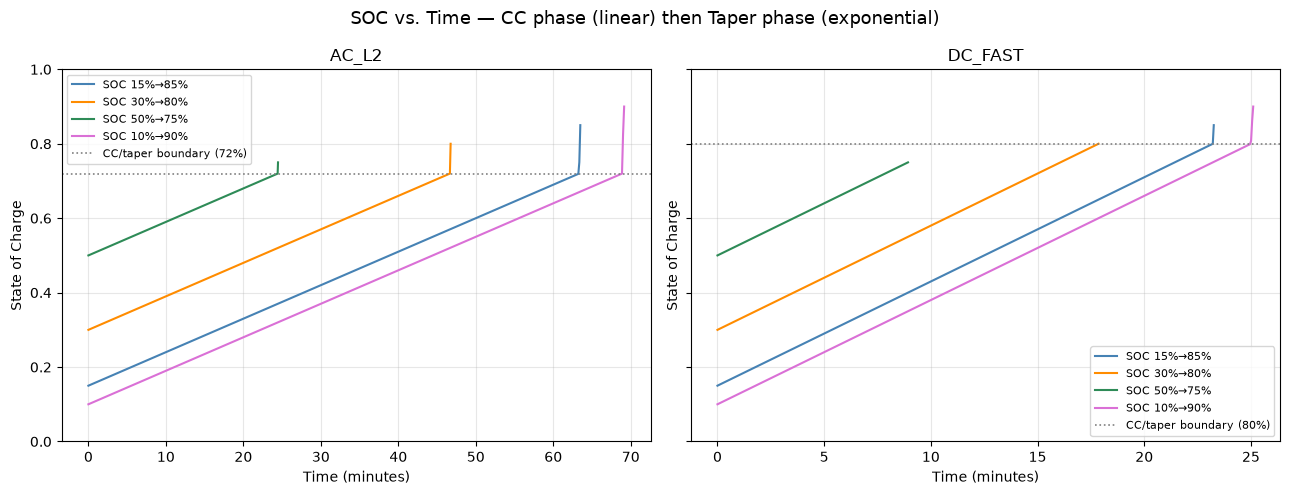

In [5]:
def soc_trace(initial_soc, target_soc, curve, n_points=500):
    """Build (time_minutes, soc) arrays tracing the session from start to end."""
    cc_soc  = curve["cc_soc"]
    cc_rate = curve["cc_rate_soc_per_min"]
    taper_k = curve["taper_k"]

    t_base = compute_base_minutes(initial_soc, target_soc, curve)
    times = np.linspace(0, t_base, n_points)
    socs  = np.zeros(n_points)

    # Time at which CC phase ends (if applicable)
    if initial_soc < cc_soc:
        t_cc_end = (cc_soc - initial_soc) / cc_rate
    else:
        t_cc_end = 0.0

    for i, t in enumerate(times):
        if t <= t_cc_end:
            # Linear rise
            socs[i] = initial_soc + cc_rate * t
        else:
            # Exponential taper starting from cc_soc
            dt_taper = t - t_cc_end
            # Invert: SOC(t) = 1 - (1 - cc_soc) * exp(-k * dt)
            socs[i] = 1.0 - (1.0 - cc_soc) * math.exp(-taper_k * dt_taper)

    return times, socs


fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
example_sessions = [(0.15, 0.85), (0.30, 0.80), (0.50, 0.75), (0.10, 0.90)]
colors = ["steelblue", "darkorange", "seagreen", "orchid"]

for ax, (name, curve) in zip(axes, CURVE_PRESETS.items()):
    for (i_soc, t_soc), col in zip(example_sessions, colors):
        times, socs = soc_trace(i_soc, t_soc, curve)
        ax.plot(times, socs, color=col, label=f"SOC {i_soc:.0%}→{t_soc:.0%}")
    ax.axhline(curve["cc_soc"], color="gray", linestyle=":", linewidth=1.2, label=f"CC/taper boundary ({curve['cc_soc']:.0%})")
    ax.set_title(f"{name.upper()}")
    ax.set_xlabel("Time (minutes)")
    ax.set_ylabel("State of Charge")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.suptitle("SOC vs. Time — CC phase (linear) then Taper phase (exponential)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Scaling, Jitter, and Calibration

The raw `t_base` minutes go through three further adjustments before becoming the session duration used by the bay calculator.

### 6a. Duration scale

A fixed multiplier accounts for real-world overhead (cable handling, payment, walk time):

$$t_{\text{scaled}} = t_{\text{base}} \times \text{duration\_scale}$$

### 6b. Duration jitter

A multiplicative Gaussian jitter models natural variation between drivers and vehicles:

$$\text{jitter} \sim \mathcal{N}(1.0,\ \sigma_{\text{jitter}}) \quad\text{clamped to } [0.7, \infty)$$

$$t_{\text{jittered}} = t_{\text{scaled}} \times \text{jitter}$$

### 6c. Calibration to `avg_service_time`

The model is anchored to the user-supplied `avg_service_time` (in minutes) so that existing defaults remain intuitive regardless of which curve is selected.  A reference session length is precomputed for each curve type:

| Curve | Reference minutes |
|---|---|
| `ac_l2` | 55 min |
| `dc_fast` | 28 min |

$$\text{calibration} = \frac{\text{avg\_service\_time}}{\text{reference\_minutes}} \quad\text{clamped to } [0.5, \infty)$$

$$t_{\text{calibrated}} = t_{\text{jittered}} \times \text{calibration}$$

### 6d. Entry/exit buffer

A random Gaussian buffer (mean 4 min, std 1 min, clamped ≥ 0) is added to represent the time a bay is occupied but not actively charging:

$$t_{\text{final}} = \max\!\left(5,\ t_{\text{calibrated}} + \mathcal{N}^+(4, 1)\right)$$

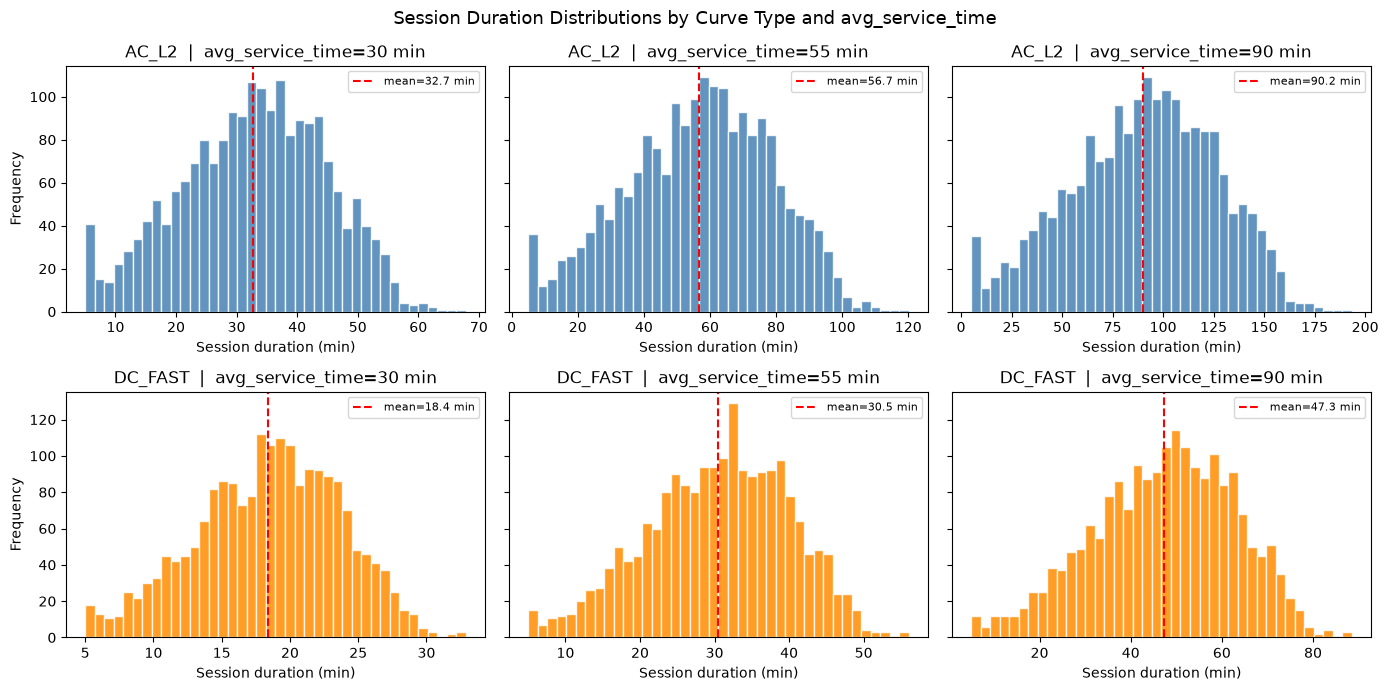

In [6]:
def sample_session_minutes(curve_name, avg_service_time=55.0,
                           buffer_mean=4.0, buffer_std=1.0):
    """Full pipeline: draw SOC pair → compute base → scale → jitter → calibrate → buffer."""
    curve = CURVE_PRESETS[curve_name]

    # SOC draw
    initial_soc = random.betavariate(2.2, 4.8)
    target_soc  = random.uniform(0.75, 0.90)
    if target_soc <= initial_soc:
        target_soc = min(0.95, initial_soc + 0.10)

    # Base minutes from CC + taper
    t_base = compute_base_minutes(initial_soc, target_soc, curve)

    # Scale
    t_scaled = t_base * curve["duration_scale"]

    # Jitter
    jitter = random.gauss(1.0, curve["duration_jitter"])
    t_jittered = t_scaled * max(0.7, jitter)

    # Calibration
    ref = curve["reference_minutes"]
    calibration = max(0.5, avg_service_time / ref)
    t_calibrated = t_jittered * calibration

    # Entry/exit buffer
    buffer = max(0.0, random.gauss(buffer_mean, buffer_std))

    return max(5.0, t_calibrated + buffer)


# Show the effect of avg_service_time on resulting distributions
avg_times = [30, 55, 90]
n = 2000

fig, axes = plt.subplots(len(CURVE_PRESETS), len(avg_times), figsize=(14, 7), sharey="row")

for row, (curve_name, curve) in enumerate(CURVE_PRESETS.items()):
    for col, avg in enumerate(avg_times):
        random.seed(42)
        durations = [sample_session_minutes(curve_name, avg_service_time=avg) for _ in range(n)]
        axes[row, col].hist(durations, bins=40, color="steelblue" if curve_name == "ac_l2" else "darkorange",
                            edgecolor="white", alpha=0.85)
        axes[row, col].axvline(np.mean(durations), color="red", linestyle="--",
                               label=f"mean={np.mean(durations):.1f} min")
        axes[row, col].set_title(f"{curve_name.upper()}  |  avg_service_time={avg} min")
        axes[row, col].set_xlabel("Session duration (min)")
        axes[row, col].legend(fontsize=8)
        if col == 0:
            axes[row, col].set_ylabel("Frequency")

plt.suptitle("Session Duration Distributions by Curve Type and avg_service_time", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Comparing Curve Types Side-by-Side

The key practical difference between AC L2 and DC fast is captured in the duration distributions.  Below we overlay both at the same `avg_service_time` setting to make the comparison clear.

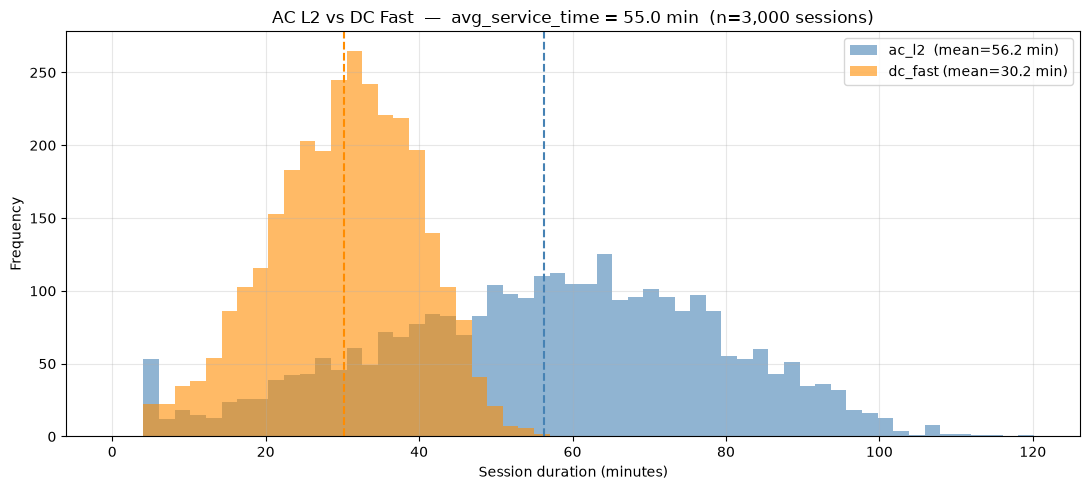

AC L2    percentiles: p25=41.0  p50=57.6  p75=72.2  p95=90.6
DC Fast  percentiles: p25=23.8  p50=30.9  p75=37.3  p95=44.9


In [7]:
avg_service_time = 55.0
n = 3000

random.seed(42)
ac_durations = [sample_session_minutes("ac_l2",  avg_service_time) for _ in range(n)]
random.seed(42)
dc_durations = [sample_session_minutes("dc_fast", avg_service_time) for _ in range(n)]

fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(0, max(max(ac_durations), max(dc_durations)), 60)
ax.hist(ac_durations, bins=bins, alpha=0.6, color="steelblue", label=f"ac_l2  (mean={np.mean(ac_durations):.1f} min)")
ax.hist(dc_durations, bins=bins, alpha=0.6, color="darkorange", label=f"dc_fast (mean={np.mean(dc_durations):.1f} min)")
ax.axvline(np.mean(ac_durations),  color="steelblue",  linestyle="--", linewidth=1.5)
ax.axvline(np.mean(dc_durations), color="darkorange", linestyle="--", linewidth=1.5)
ax.set_xlabel("Session duration (minutes)")
ax.set_ylabel("Frequency")
ax.set_title(f"AC L2 vs DC Fast  —  avg_service_time = {avg_service_time} min  (n={n:,} sessions)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AC L2    percentiles: p25={np.percentile(ac_durations,25):.1f}  p50={np.percentile(ac_durations,50):.1f}  p75={np.percentile(ac_durations,75):.1f}  p95={np.percentile(ac_durations,95):.1f}")
print(f"DC Fast  percentiles: p25={np.percentile(dc_durations,25):.1f}  p50={np.percentile(dc_durations,50):.1f}  p75={np.percentile(dc_durations,75):.1f}  p95={np.percentile(dc_durations,95):.1f}")

## 8. End-to-End: From Sessions to Bay Count

`BayCalculator.calc_all_hours` ties everything together.  For each hour:

1. Compute the number of sessions from `total_sessions_per_day × hourly_proportion`.
2. For each session, sample a duration using the curve model → convert to **bay-hours** (`minutes / 60`).
3. Sum the bay-hours required in that hour.
4. Round up with `math.ceil` to get the integer bay count.
5. Utilisation = `required_bay_hours / bays_provided`.

$$\text{bays\_required}_{h} = \left\lceil \sum_{i=1}^{N_h} \frac{t_i}{60} \right\rceil$$

Below is a self-contained simulation using a commuter double-peak profile.

Peak demand: 14 bays at 17:00
Utilisation at peak: 99.9%


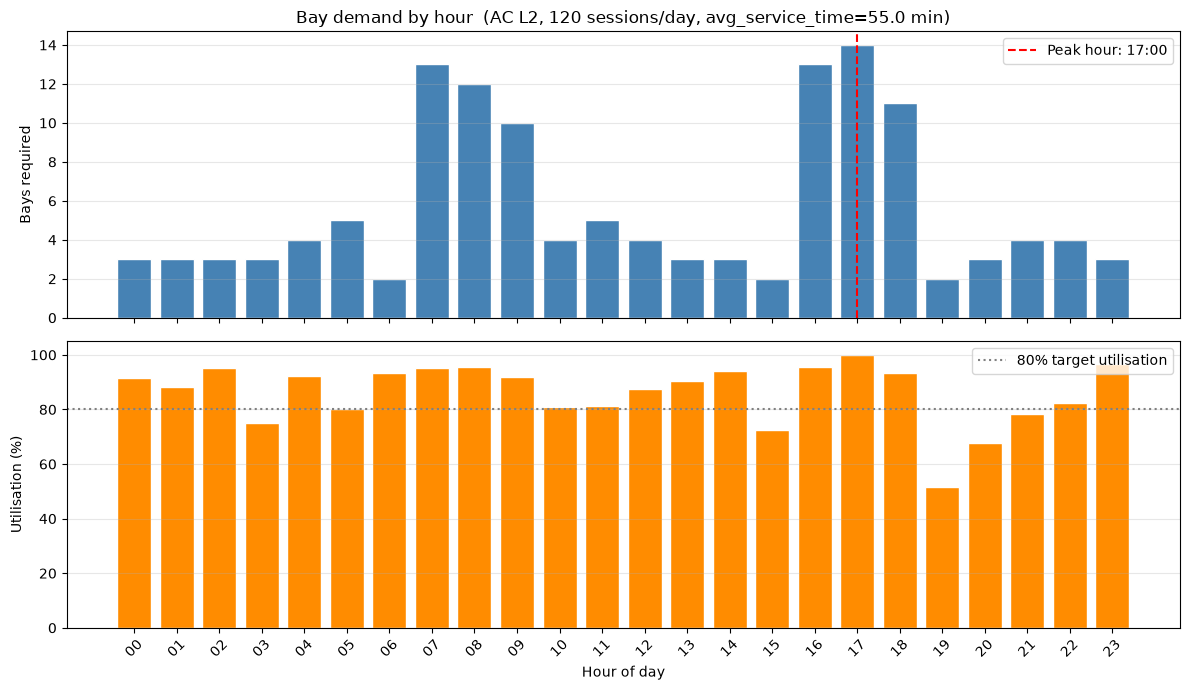

In [8]:
# Commuter double-peak day profile (matches DayProfile.commuter_double_peak)
raw_dist = [0.0] * 24
for i in range(7, 10):   raw_dist[i] = 0.10   # morning peak
for i in range(16, 19):  raw_dist[i] = 0.10   # evening peak
total = sum(raw_dist)
leftover = 1.0 - total
off_peak_hours = sum(1 for v in raw_dist if v == 0.0)
for i in range(24):
    if raw_dist[i] == 0.0:
        raw_dist[i] = leftover / off_peak_hours
hourly_dist = [v / sum(raw_dist) for v in raw_dist]   # normalise

total_sessions = 120
avg_service_time = 55.0

random.seed(0)
bays_per_hour = []
util_per_hour  = []

for hour, prop in enumerate(hourly_dist):
    session_count = max(0, round(prop * total_sessions))
    bay_hours = sum(
        sample_session_minutes("ac_l2", avg_service_time) / 60.0
        for _ in range(session_count)
    )
    bays = math.ceil(bay_hours)
    bays_per_hour.append(bays)
    util_per_hour.append(bay_hours / bays if bays > 0 else 0.0)

peak_hour = int(np.argmax(bays_per_hour))
print(f"Peak demand: {bays_per_hour[peak_hour]} bays at {peak_hour:02d}:00")
print(f"Utilisation at peak: {util_per_hour[peak_hour]:.1%}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
hours = list(range(24))
ax1.bar(hours, bays_per_hour, color="steelblue", edgecolor="white")
ax1.axvline(peak_hour, color="red", linestyle="--", label=f"Peak hour: {peak_hour:02d}:00")
ax1.set_ylabel("Bays required")
ax1.set_title(f"Bay demand by hour  (AC L2, {total_sessions} sessions/day, avg_service_time={avg_service_time} min)")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

ax2.bar(hours, [u * 100 for u in util_per_hour], color="darkorange", edgecolor="white")
ax2.axhline(80, color="gray", linestyle=":", label="80% target utilisation")
ax2.set_ylabel("Utilisation (%)")
ax2.set_xlabel("Hour of day")
ax2.set_xticks(hours)
ax2.set_xticklabels([f"{h:02d}" for h in hours], rotation=45)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Parameter Sensitivity

How sensitive is the peak bay count to changes in `avg_service_time` and the choice of curve?

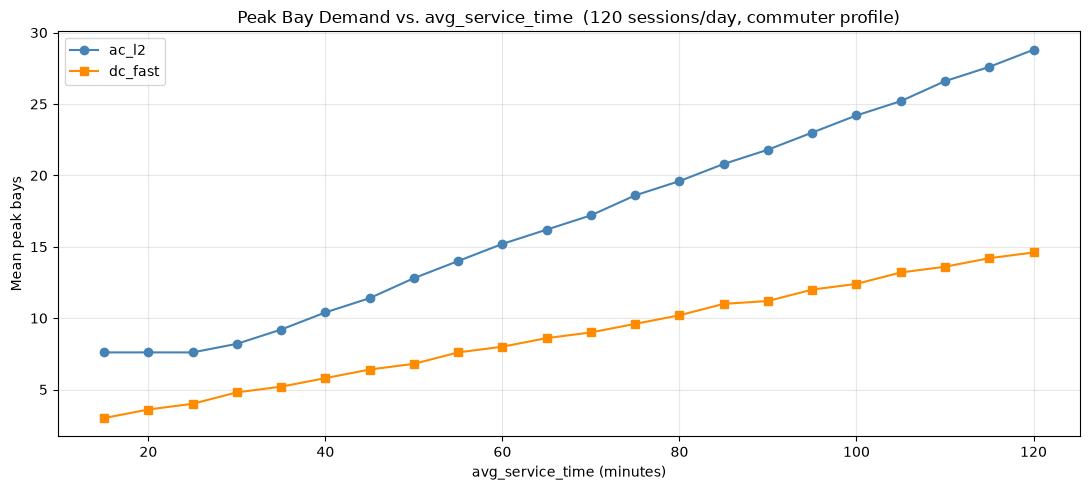

In [9]:
service_times = np.arange(15, 121, 5)
curve_names   = ["ac_l2", "dc_fast"]
n_runs        = 5   # average over a few seeds to reduce noise

results = {c: [] for c in curve_names}

for avg in service_times:
    for curve_name in curve_names:
        peak_totals = []
        for seed in range(n_runs):
            random.seed(seed)
            peaks = []
            for prop in hourly_dist:
                sc = max(0, round(prop * total_sessions))
                bh = sum(sample_session_minutes(curve_name, float(avg)) / 60.0 for _ in range(sc))
                peaks.append(math.ceil(bh))
            peak_totals.append(max(peaks))
        results[curve_name].append(np.mean(peak_totals))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(service_times, results["ac_l2"],  "o-", color="steelblue",  label="ac_l2")
ax.plot(service_times, results["dc_fast"], "s-", color="darkorange", label="dc_fast")
ax.set_xlabel("avg_service_time (minutes)")
ax.set_ylabel("Mean peak bays")
ax.set_title(f"Peak Bay Demand vs. avg_service_time  ({total_sessions} sessions/day, commuter profile)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()